In [1]:
import pandas as pd

df = pd.read_csv("ifood_df-selected-columns.csv")

df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,58138.0,0,0,58,635,88,546,172,88,88
1,46344.0,1,1,38,11,1,6,2,1,6
2,71613.0,0,0,26,426,49,127,111,21,42
3,26646.0,1,0,26,11,4,20,10,3,5
4,58293.0,1,0,94,173,43,118,46,27,15


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Income            2205 non-null   float64
 1   Kidhome           2205 non-null   int64  
 2   Teenhome          2205 non-null   int64  
 3   Recency           2205 non-null   int64  
 4   MntWines          2205 non-null   int64  
 5   MntFruits         2205 non-null   int64  
 6   MntMeatProducts   2205 non-null   int64  
 7   MntFishProducts   2205 non-null   int64  
 8   MntSweetProducts  2205 non-null   int64  
 9   MntGoldProds      2205 non-null   int64  
dtypes: float64(1), int64(9)
memory usage: 172.4 KB


In [3]:
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000


In [4]:
df.isnull().sum()

,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0
MntFishProducts,0
MntSweetProducts,0
MntGoldProds,0


In [5]:
df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

df[["Income","Total_Spending"]].head()

,Income,Total_Spending
0,58138.0,1617
1,46344.0,27
2,71613.0,776
3,26646.0,53
4,58293.0,422


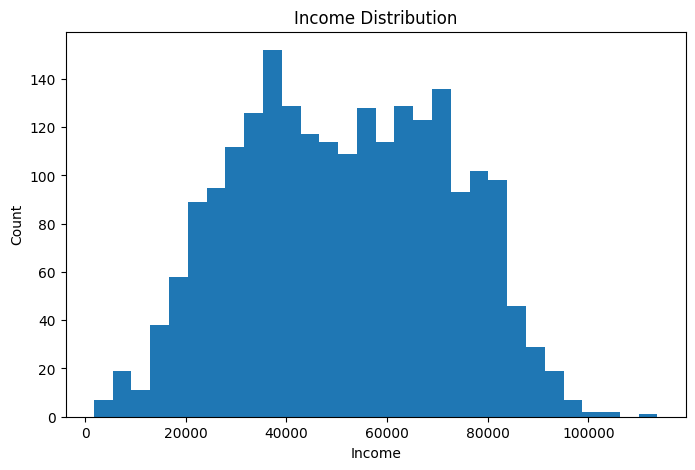

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Income"], bins=30)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")

plt.show()

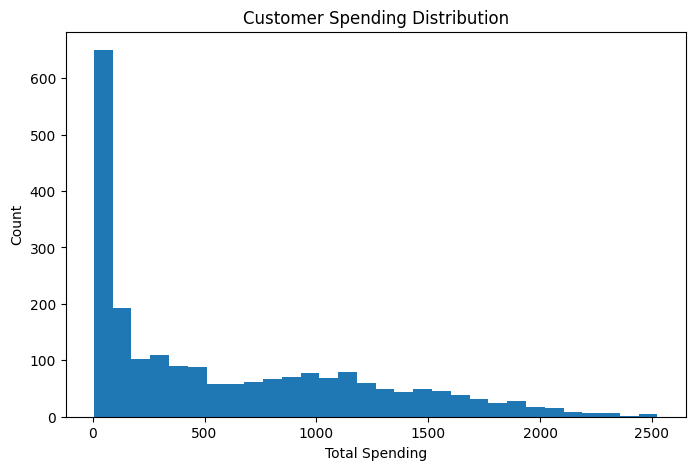

In [7]:
plt.figure(figsize=(8,5))

plt.hist(df["Total_Spending"], bins=30)

plt.title("Customer Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Count")

plt.show()

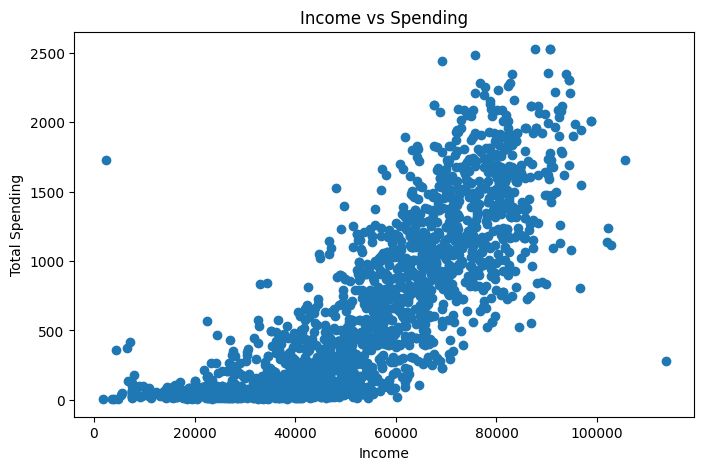

In [8]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Income"],
    df["Total_Spending"]
)

plt.title("Income vs Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")

plt.show()

In [9]:
import seaborn as sns

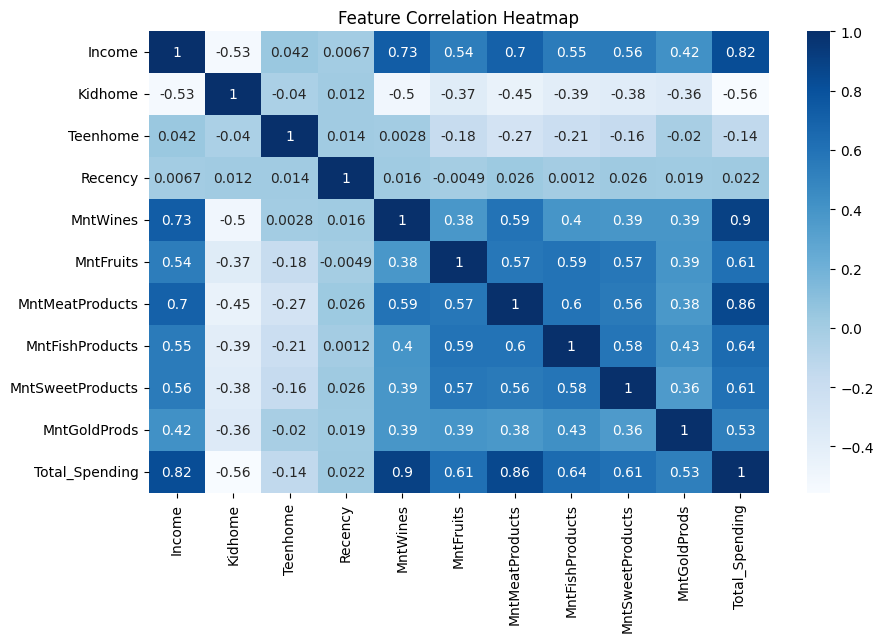

In [10]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [11]:
from sklearn.preprocessing import StandardScaler

features = df[[
    "Income",
    "Total_Spending"
]]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[ 0.31465086,  1.67932338],
       [-0.25487741, -0.96389748],
       [ 0.96535404,  0.28124241],
       [-1.20608716, -0.920675  ],
       [ 0.32213575, -0.30724827]])

In [13]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)


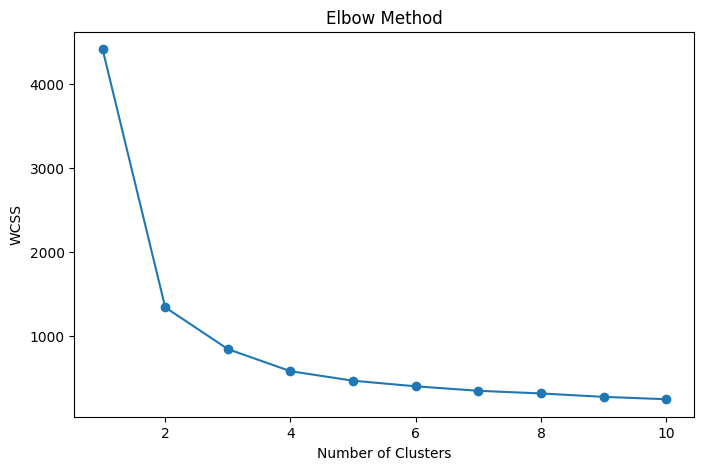

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(
    scaled_features
)

df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Total_Spending,Cluster
0,58138.0,0,0,58,635,88,546,172,88,88,1617,0
1,46344.0,1,1,38,11,1,6,2,1,6,27,3
2,71613.0,0,0,26,426,49,127,111,21,42,776,2
3,26646.0,1,0,26,11,4,20,10,3,5,53,1
4,58293.0,1,0,94,173,43,118,46,27,15,422,3


In [18]:
df["Cluster"].value_counts()

,count
Cluster,
1,673
3,617
2,549
0,366


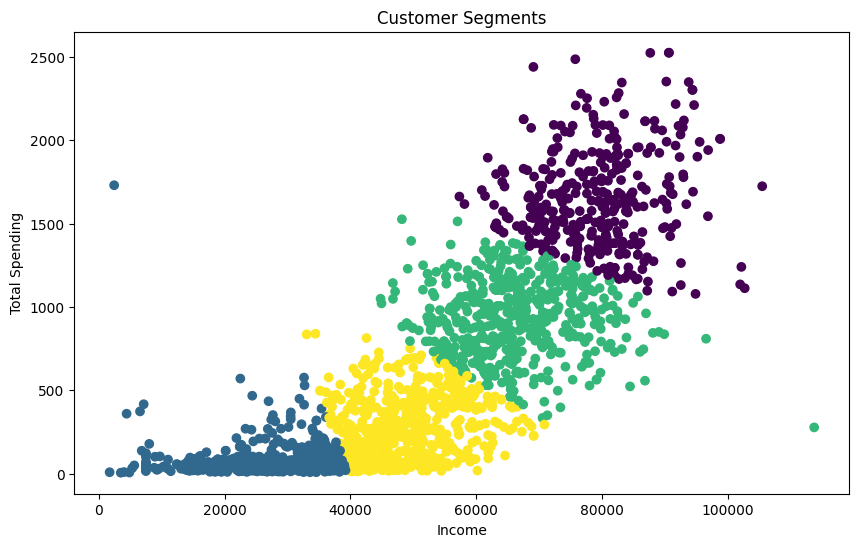

In [19]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Income"],
    df["Total_Spending"],
    c=df["Cluster"]
)

plt.title("Customer Segments")
plt.xlabel("Income")
plt.ylabel("Total Spending")

plt.show()

In [20]:
df.groupby("Cluster")[[
    "Income",
    "Total_Spending"
]].mean()

,Income,Total_Spending
Cluster,,
0,79154.696721,1644.726776
1,27321.267459,76.439822
2,66460.826958,937.092896
3,48593.019449,275.792545
